Anomalous glacier:   
RGI60-15.11833, GRI60-15.12579 for 2000-2022.



### Elevation change drived by altimeter 


In [1]:
import h5py
import numpy as np
from glob import glob
from shapely.geometry import Point
import rasterio as rio
import geopandas as gpd
from rasterio.mask import mask
import matplotlib.pyplot as plt 
import pandas as pd 


In [2]:
def dif_ele_dem(dem_rio, gla_gpd, path_ele):
    ele_dict = {}
    with h5py.File(path_ele, 'r') as f_read:
      for key in f_read.keys(): ele_dict[key] = f_read[key][:]
    pts = list(zip(ele_dict['lon'], ele_dict['lat']))
    geom_fp = [Point(pt) for pt in pts]
    dict_gpd = {'h': ele_dict['h'], 'geometry':geom_fp}
    ele_gpd = gpd.GeoDataFrame(dict_gpd, crs="EPSG:4326")
    gla_gpd_contain = gla_gpd['geometry'].values[0].contains(ele_gpd['geometry'])
    if gla_gpd_contain.sum() > 0:
      ele_gpd_sel = ele_gpd[gla_gpd_contain]
      pts_x = [pt.xy[0][0] for pt in ele_gpd_sel['geometry'].values]
      pts_y = [pt.xy[1][0] for pt in ele_gpd_sel['geometry'].values]
      rows, cols = rio.transform.rowcol(transform=dem_rio.transform, xs = pts_x, ys = pts_y)
      dif_ele = ele_gpd_sel['h'].values - dem_rio.read(1)[rows, cols]
      dif_ele[abs(dif_ele)>100] = np.nan
      dif_ele_mean = np.nanmean(dif_ele)
    else: dif_ele_mean, ele_gpd_sel = np.nan, np.nan
    return dif_ele_mean, ele_gpd_sel



In [7]:
path_rgi60_setp = 'data/land-cover/rgi60/rgi60_setp.shp'
path_dem = 'data/dem-data/srtm-c/tiles/tile_29_96.tif'
path_result_glacier = 'data/ele-change-result/ele_change_glaciers.pkl'
paths_isat1 = sorted(glob('data/icesat-1/GLAH14-????/tiles/tile_29_96.h5'))
paths_isat2 = sorted(glob('data/icesat-2/ATL06-????/tiles/tile_29_96.h5'))
paths_cryo2 = sorted(glob('data/cryosat-2/eolis-point-????/tiles/tile_29_96.h5')) 
path_Hugonnet_wgs84 = 'data/ele-change-dset-hugonnet/N29E096_2000-01-01_2010-01-01_dhdt_wgs84.tif'
paths_isat2


['data/icesat-2/ATL06-2018/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2019/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2020/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2021/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2022/tiles/tile_29_96.h5']

In [8]:
rgi60_glaciers = gpd.read_file(path_rgi60_setp)
dem_rio = rio.open(path_dem)
ele_change_hugonnet = rio.open(path_Hugonnet_wgs84 )
result_glaciers = pd.read_pickle(path_result_glacier)


Glacier: RGI60-15.12579


Glacier elevation rate: 0.8084229842678063


Text(0, 0.5, 'Glacier elevation change')

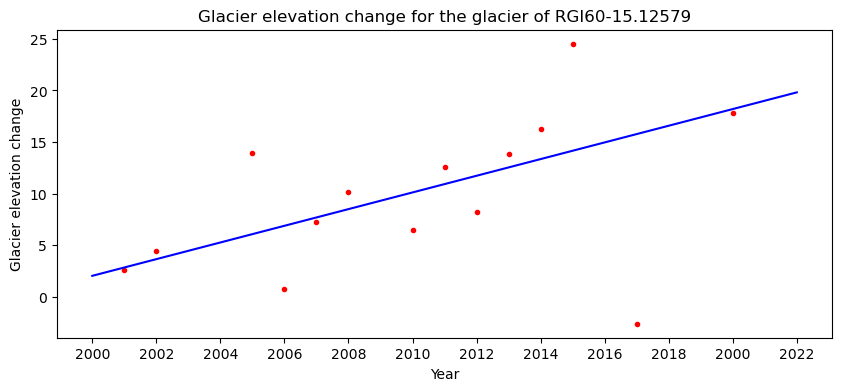

In [9]:
## Our result
fig, ax = plt.subplots(1,1,figsize=(10,4))
gla_sta_1 = result_glaciers[result_glaciers.rgi_id=='RGI60-15.12579']
print('Glacier elevation rate:', gla_sta_1['rate'].values[0])
plt.plot(gla_sta_1['ele_change'].values[0], '.r')
plt.plot(gla_sta_1['ele_change_fitting'].values[0], '-b', label='ele_change_rate')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]);
ax.set_xticklabels(['2000', '2002','2004','2006','2008', \
                    '2010','2012','2014','2016','2018','2000','2022']);
ax.set_title('Glacier elevation change for the glacier of RGI60-15.12579')
ax.set_xlabel('Year')
ax.set_ylabel('Glacier elevation change')


1. compare with the altimetry-derived result

In [10]:
gla_sel_1 = rgi60_glaciers[rgi60_glaciers['RGIId']=='RGI60-15.12579']
gla_sel_1 = gla_sel_1.to_crs(4326)


In [11]:
dif_ele_means = []
for path in paths_cryo2:
  print(path)
  dif_ele_mean, _ = dif_ele_dem(dem_rio=dem_rio, gla_gpd=gla_sel_1, path_ele=path)
  dif_ele_means.append(dif_ele_mean)
  print(dif_ele_mean)


data/cryosat-2/eolis-point-2010/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2011/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2012/tiles/tile_29_96.h5
54.77173
data/cryosat-2/eolis-point-2013/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2014/tiles/tile_29_96.h5
-5.0148926
data/cryosat-2/eolis-point-2015/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2016/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2017/tiles/tile_29_96.h5
-3.267741
data/cryosat-2/eolis-point-2018/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2019/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2020/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2021/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2022/tiles/tile_29_96.h5
nan


In [ ]:
print(np.nanmean(dif_ele_means))
np.nanmean(dif_ele_means)/22


15.496364990870157


0.7043802268577344

Text(0.5, 1.0, 'ICESat-2 data for RGI60-15.12579')

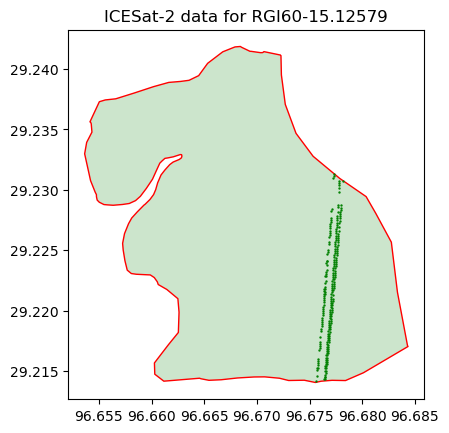

In [12]:
dif_ele_mean, ele_gpd_sel = dif_ele_dem(dem_rio=dem_rio, gla_gpd=gla_sel_1, path_ele=paths_isat2[2])
fig, ax = plt.subplots(1,1)
gla_sel_1.plot(ax=ax, facecolor='green', alpha=0.2)
gla_sel_1.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)
ele_gpd_sel.plot(ax=ax, color='green', markersize=0.5)
ax.set_title('ICESat-2 data for RGI60-15.12579')



2. compare with the Hugonnet result.

In [13]:
masked_image, masked_transform = mask(ele_change_hugonnet, gla_sel_1['geometry'], crop=True)
out_meta = ele_change_hugonnet.meta
out_meta.update({"driver": "GTiff",
                 "height": masked_image.shape[1],
                 "width": masked_image.shape[2],
                 "transform": masked_transform})
masked_image[masked_image==-9999] = np.nan
print(np.nanmean(masked_image))


-0.26927873


In [14]:
masked_image[abs(masked_image)>1] = np.nan
print(np.nanmean(masked_image))


-0.12553146


Text(0.5, 1.0, 'Result by Hugonnet et al. for RGI60-15.12579')

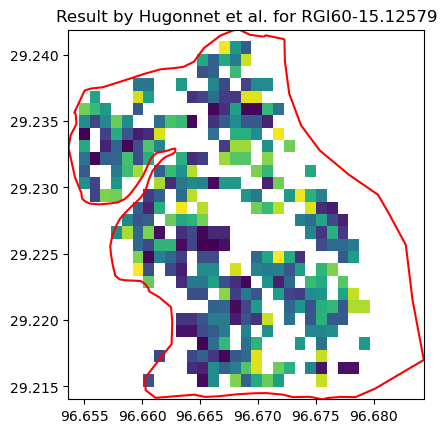

In [15]:
bounds = gla_sel_1['geometry'].bounds.values[0]
extent = [bounds[0], bounds[2], bounds[1], bounds[3]]
fig, ax = plt.subplots(1,1)
ax.imshow(masked_image[0], extent=extent)
gla_sel_1.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5)
ax.set_title('Result by Hugonnet et al. for RGI60-15.12579')


Glacier: RGI60-15.11833  

Glacier elevation rate: -0.015420280345554996


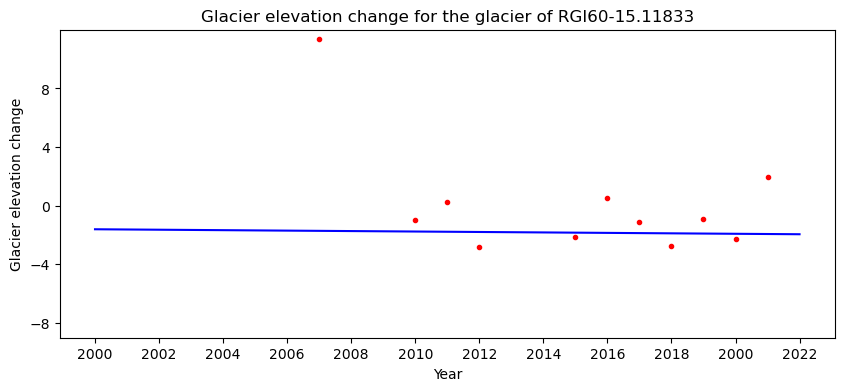

In [16]:
## Our result
fig, ax = plt.subplots(1,1,figsize=(10,4))
gla_sta_1 = result_glaciers[result_glaciers.rgi_id=='RGI60-15.11833']
print('Glacier elevation rate:', gla_sta_1['rate'].values[0])
plt.plot(gla_sta_1['ele_change'].values[0], '.r')
plt.plot(gla_sta_1['ele_change_fitting'].values[0], '-b', label='ele_change_rate')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]);
ax.set_xticklabels(['2000', '2002','2004','2006','2008', \
                    '2010','2012','2014','2016','2018','2000','2022']);
ax.set_title('Glacier elevation change for the glacier of RGI60-15.11833')
ax.set_xlabel('Year')
ax.set_ylabel('Glacier elevation change')
ax.set_ylim(-9,12)
ax.set_yticks([-8,-4,0, 4, 8]);


1. compare with the altimetry-derived result

In [17]:
gla_sel_2 = rgi60_glaciers[rgi60_glaciers['RGIId']=='RGI60-15.11833']
gla_sel_2 = gla_sel_2.to_crs(4326)


In [18]:
dif_ele_means = []
for path in paths_cryo2:
  print(path)
  dif_ele_mean, _ = dif_ele_dem(dem_rio=dem_rio, gla_gpd=gla_sel_2, path_ele=path)
  dif_ele_means.append(dif_ele_mean)
  print(dif_ele_mean)


data/cryosat-2/eolis-point-2010/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2011/tiles/tile_29_96.h5
-16.99868
data/cryosat-2/eolis-point-2012/tiles/tile_29_96.h5
-16.842743
data/cryosat-2/eolis-point-2013/tiles/tile_29_96.h5
-1.4591064
data/cryosat-2/eolis-point-2014/tiles/tile_29_96.h5
-15.358154
data/cryosat-2/eolis-point-2015/tiles/tile_29_96.h5
-27.232536
data/cryosat-2/eolis-point-2016/tiles/tile_29_96.h5
nan
data/cryosat-2/eolis-point-2017/tiles/tile_29_96.h5
-17.54562
data/cryosat-2/eolis-point-2018/tiles/tile_29_96.h5
-20.700684
data/cryosat-2/eolis-point-2019/tiles/tile_29_96.h5
-25.143023
data/cryosat-2/eolis-point-2020/tiles/tile_29_96.h5
-33.54236
data/cryosat-2/eolis-point-2021/tiles/tile_29_96.h5
-18.82387
data/cryosat-2/eolis-point-2022/tiles/tile_29_96.h5
-44.52881


In [19]:
print(np.nanmean(dif_ele_means))
np.nanmean(dif_ele_means)/22


-21.652325716885652


-0.9841966234948024

2. compare with the Hugonnet result.

In [20]:
masked_image, masked_transform = mask(ele_change_hugonnet, gla_sel_2['geometry'], crop=True)
out_meta = ele_change_hugonnet.meta
out_meta.update({"driver": "GTiff",
                 "height": masked_image.shape[1],
                 "width": masked_image.shape[2],
                 "transform": masked_transform})
masked_image[masked_image==-9999] = np.nan
print(np.nanmean(masked_image))


-0.38403732


In [21]:
masked_image[abs(masked_image)>1] = np.nan
print(np.nanmean(masked_image))


-0.079862654


Text(0.5, 1.0, 'Result by Hugonnet et al.RGI60-15.11833')

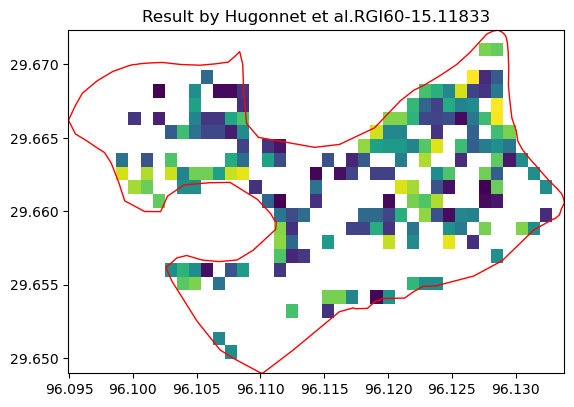

In [22]:
bounds = gla_sel_2['geometry'].bounds.values[0]
extent = [bounds[0], bounds[2], bounds[1], bounds[3]]
fig, ax = plt.subplots(1,1)
ax.imshow(masked_image[0], extent=extent)
gla_sel_2.plot(ax=ax, facecolor='none', edgecolor='red')
ax.set_title('Result by Hugonnet et al.RGI60-15.11833')
